In [ ]:
!python -m pip install -U matplotlib

In [ ]:
!pip install seaborn

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn import manifold

%config InlineBackend.figure_format = 'retina'

In [44]:
tsne = manifold.TSNE(n_components=2, init='random',random_state=36, n_jobs=5)
gex_features_df = pd.read_csv('./fig2_reproduce_data/Original_Distribution.csv', index_col=0)
labels_df = gex_features_df['Data']

del gex_features_df['Data']

In [45]:
ori_gex_y = tsne.fit_transform(gex_features_df)
ori_encoder_feature_df = pd.DataFrame(ori_gex_y, columns=['x','y'])
ori_encoder_feature_df['Data'] = labels_df.values

In [71]:
tsne = manifold.TSNE(n_components=2, init='random',random_state=42, n_jobs=5)

gex_features_df = pd.read_csv('./fig2_reproduce_data/Pretrained_Data.csv', index_col=0)
labels_df = gex_features_df['Data']

del gex_features_df['Data']

In [72]:
gex_tensor_pretrain_encoded = tsne.fit_transform(gex_features_df)
gex_tensor_pretrain_encoded_df = pd.DataFrame(gex_tensor_pretrain_encoded, columns=['x','y'])

gex_tensor_pretrain_encoded_df['Data'] = labels_df.values

In [68]:
tsne = manifold.TSNE(n_components=2,random_state=42, n_jobs=5)

gex_features_df = pd.read_csv('./fig2_reproduce_data/task_spefic_train_step0_Data.csv', index_col=0)
labels_df = gex_features_df['Data']
del gex_features_df['Data']


In [69]:
encoded_feature_TST_step0_y = tsne.fit_transform(gex_features_df)
encoded_feature_tensor_encoded_df_TST_step0_y = pd.DataFrame(encoded_feature_TST_step0_y, columns=['x','y'])
encoded_feature_tensor_encoded_df_TST_step0_y['Data'] = labels_df.values

In [47]:
tsne = manifold.TSNE(n_components=2,random_state=42, n_jobs=5)

gex_features_df = pd.read_csv('./fig2_reproduce_data/task_spefic_train_step0_unspecific_Data.csv', index_col=0)
labels_df = gex_features_df['Data']
del gex_features_df['Data']

In [48]:
encoded_feature_UTST_step0_y = tsne.fit_transform(gex_features_df)
encoded_feature_tensor_encoded_df_UTST_step0_y = pd.DataFrame(encoded_feature_UTST_step0_y, columns=['x','y'])
encoded_feature_tensor_encoded_df_UTST_step0_y['Data'] = labels_df.values

In [49]:
tsne = manifold.TSNE(n_components=2,random_state=42, n_jobs=5)

gex_features_df = pd.read_csv('./fig2_reproduce_data/task_spefic_train_beststep_Data.csv', index_col=0)
labels_df = gex_features_df['Data']
del gex_features_df['Data']

In [50]:
encoded_feature_TST_beststep_y = tsne.fit_transform(gex_features_df)
encoded_feature_tensor_encoded_df_TST_beststep_y = pd.DataFrame(encoded_feature_TST_beststep_y, columns=['x','y'])
encoded_feature_tensor_encoded_df_TST_beststep_y['Data'] = labels_df.values

In [66]:
tsne = manifold.TSNE(n_components=2,random_state=42, n_jobs=5)

gex_features_df = pd.read_csv('./fig2_reproduce_data/task_spefic_train_beststep_unspecific_Data.csv', index_col=0)
labels_df = gex_features_df['Data']
del gex_features_df['Data']

In [67]:
encoded_feature_UTST_best_step_y = tsne.fit_transform(gex_features_df)
encoded_feature_tensor_encoded_df_UTST_best_step_y = pd.DataFrame(encoded_feature_UTST_best_step_y, columns=['x','y'])
encoded_feature_tensor_encoded_df_UTST_best_step_y['Data'] = labels_df.values

In [63]:
TCGA_test_labels = np.load('./fig2_reproduce_data/TCGA_test_labels.npy', allow_pickle=True)
TCGA_label_dict = {0:'TCGA_test_NR',1:'TCGA_test_R'}
drug = 'Paclitaxel'

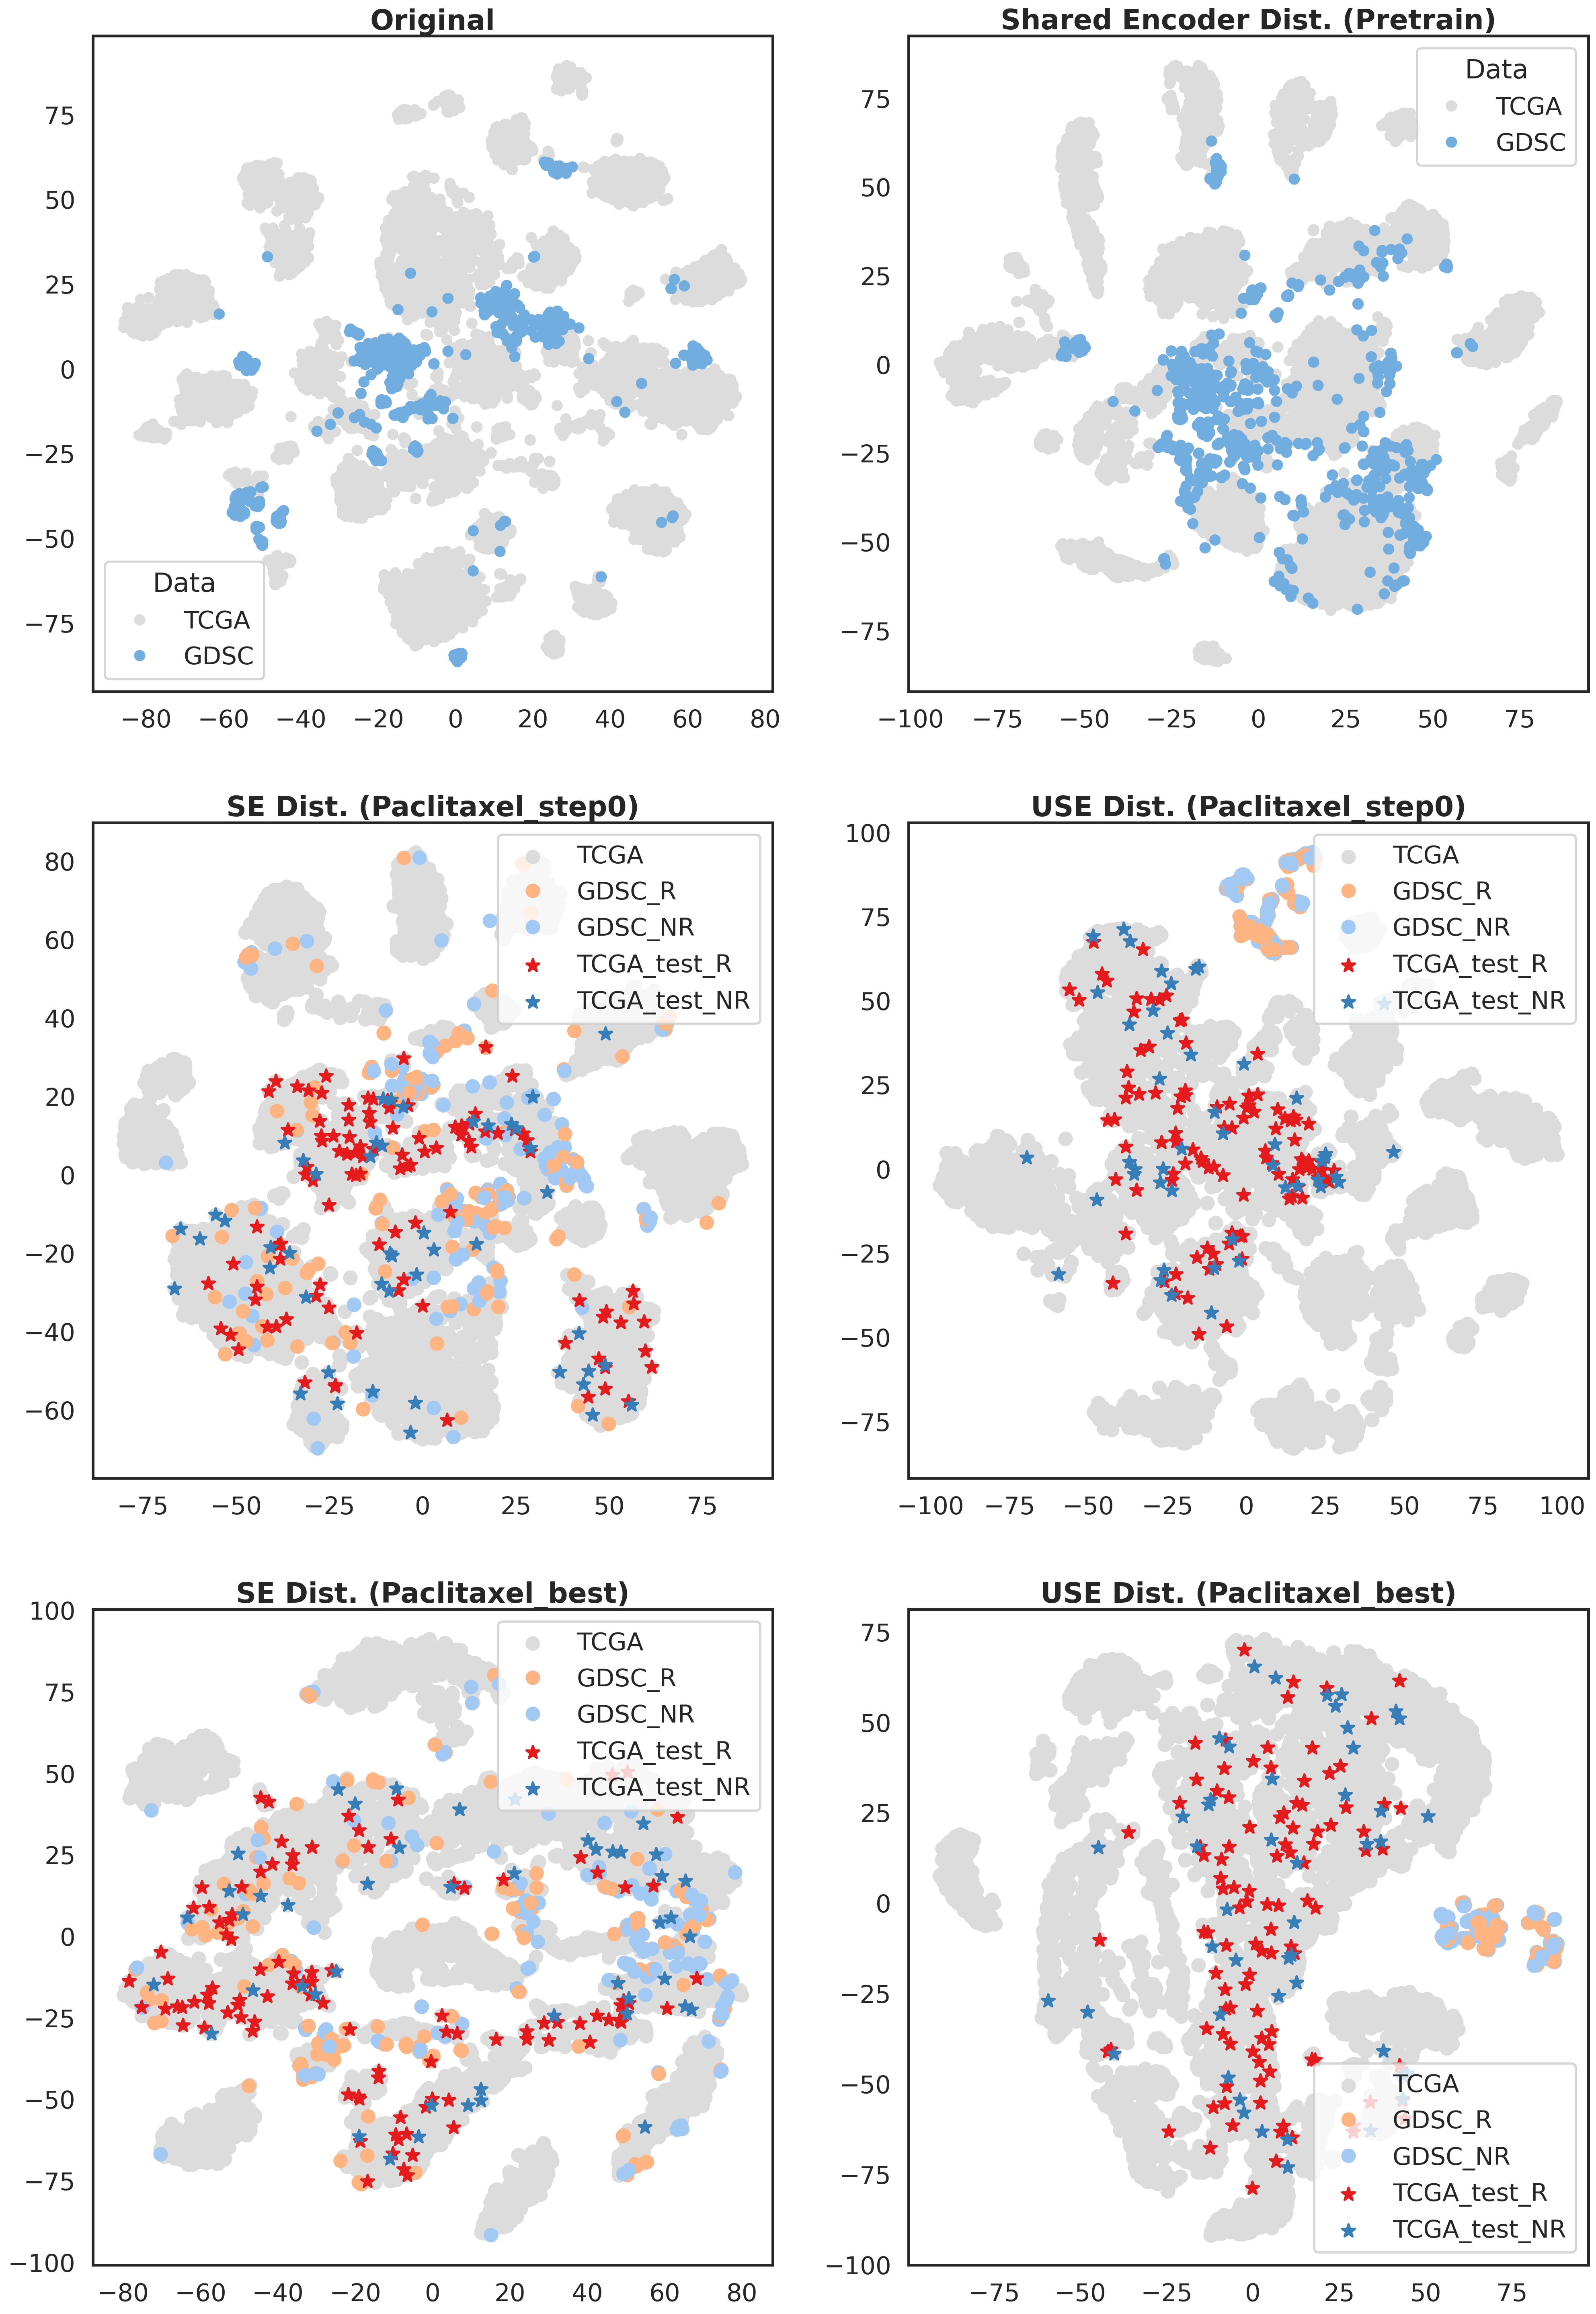

In [73]:
plt.figure(figsize=(24,36))
sns.set(font_scale = 2.0)
sns.set_style('white')
sns.set_context('poster')
# sns.set_style('whitegrid')
colors = ['#DCDCDC', '#72ADE0']
palette_ori = sns.color_palette(colors)

# palette_response = sns.color_palette(palette='pastel', n_colors=2)
# 顺：['#a1c9f4', '#ffb482']
# 反：['#ffb482', '#a1c9f4']
palette_response = sns.color_palette(['#ffb482', '#a1c9f4'])

# 三行两列第一个 Original
plt.subplot(3,2,1)

ax = sns.scatterplot(x='x',y='y',data=ori_encoder_feature_df,hue='Data', marker=".", s=300, ec="face", palette=palette_ori)

plt.xlabel("")
plt.ylabel("")

plt.title(f'Original', fontsize=25, weight='bold')

# 三行两列第二个 pretrain模型 还没经过 drug-specific train
plt.subplot(3, 2, 2)

ax = sns.scatterplot(x='x',y='y',data=gex_tensor_pretrain_encoded_df,hue='Data', marker=".", s=300, ec="face", palette=palette_ori)# , alpha=0.9)

plt.xlabel("")
plt.ylabel("")

plt.title(f'Shared Encoder Dist. (Pretrain)', fontsize=25, weight='bold')


# 三行两列第三个 drug-specific train 第一步的模型
plt.subplot(3, 2, 3)

ax = sns.scatterplot(x='x',y='y',data=encoded_feature_tensor_encoded_df_TST_step0_y[:10237],c='gainsboro', marker="o", ec="face", label="TCGA")
ax = sns.scatterplot(x='x',y='y',data=encoded_feature_tensor_encoded_df_TST_step0_y[10237:(10237+391)],hue='Data', marker="o", ec="face", palette=palette_response)

tcga_encoded_feature = encoded_feature_TST_step0_y[-151:]
plt.scatter(x=tcga_encoded_feature[torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,0], y=tcga_encoded_feature[torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,1], c='#e41a1c', marker="*", label=TCGA_label_dict[1])
plt.scatter(x=tcga_encoded_feature[~torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,0], y=tcga_encoded_feature[~torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,1], c='#377eb8', marker="*", label=TCGA_label_dict[0])



plt.xlabel('')
plt.ylabel("")

plt.title(f'SE Dist. ({drug}_step0)', fontsize=25, weight='bold');

plt.legend()
plt.grid(False)




plt.subplot(3, 2, 4)

ax = sns.scatterplot(x='x',y='y',data=encoded_feature_tensor_encoded_df_UTST_step0_y[:10237],c='gainsboro', marker="o", ec="face", label="TCGA")
ax = sns.scatterplot(x='x',y='y',data=encoded_feature_tensor_encoded_df_UTST_step0_y[10237:(10237+391)],hue='Data', marker="o", ec="face",palette=palette_response)

tcga_encoded_feature = encoded_feature_UTST_step0_y[-151:]
plt.scatter(x=tcga_encoded_feature[torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,0], y=tcga_encoded_feature[torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,1], c='#e41a1c', marker="*", label=TCGA_label_dict[1])
plt.scatter(x=tcga_encoded_feature[~torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,0], y=tcga_encoded_feature[~torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,1], c='#377eb8', marker="*", label=TCGA_label_dict[0])


plt.xlabel('')
plt.ylabel("")

plt.title(f'USE Dist. ({drug}_step0)', fontsize=25, weight='bold');
plt.legend()
plt.grid(False)
        
        
# 三行两列第三个 drug-specific train 第一步的模型
plt.subplot(3, 2, 5)

ax = sns.scatterplot(x='x',y='y',data=encoded_feature_tensor_encoded_df_TST_beststep_y[:10237],c='gainsboro', marker="o", ec="face", label="TCGA")
ax = sns.scatterplot(x='x',y='y',data=encoded_feature_tensor_encoded_df_TST_beststep_y[10237:(10237+391)],hue='Data', marker="o", ec="face", palette=palette_response)

tcga_encoded_feature = encoded_feature_TST_beststep_y[-151:]

plt.scatter(x=tcga_encoded_feature[torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,0], y=tcga_encoded_feature[torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,1], c='#e41a1c', marker="*", label=TCGA_label_dict[1])
plt.scatter(x=tcga_encoded_feature[~torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,0], y=tcga_encoded_feature[~torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,1], c='#377eb8', marker="*", label=TCGA_label_dict[0])

plt.xlabel('')
plt.ylabel("")

plt.title(f'SE Dist. ({drug}_best)', fontsize=25, weight='bold');

plt.legend()
plt.grid(False)




plt.subplot(3, 2, 6)

ax = sns.scatterplot(x='x',y='y',data=encoded_feature_tensor_encoded_df_UTST_best_step_y[:10237],c='gainsboro', marker="o", ec="face", label="TCGA")
ax = sns.scatterplot(x='x',y='y',data=encoded_feature_tensor_encoded_df_UTST_best_step_y[10237:(10237+391)],hue='Data', marker="o", ec="face",palette=palette_response)

tcga_encoded_feature = encoded_feature_UTST_best_step_y[-151:]
plt.scatter(x=tcga_encoded_feature[torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,0], y=tcga_encoded_feature[torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,1], c='#e41a1c', marker="*", label=TCGA_label_dict[1])
plt.scatter(x=tcga_encoded_feature[~torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,0], y=tcga_encoded_feature[~torch.tensor(TCGA_test_labels, dtype=torch.bool)][:,1], c='#377eb8', marker="*", label=TCGA_label_dict[0])


plt.xlabel('')
plt.ylabel("")

plt.title(f'USE Dist. ({drug}_best)', fontsize=25, weight='bold');
plt.legend()
plt.grid(False)


plt.show()
# os.makedirs('./fig_2_plot', exist_ok=True)
# plt.savefig(f"./fig_2_plot/{drug}_{seed}.pdf")